# Modelling and Evaluating Energy System Design Choices in PyPSA

This notebook demonstrates the modelling of three energy system
components in PyPSA:

1. Solar photovoltaic (PV) plant
2. Combined heat and power (CHP) plant
3. Transmission lines

For each component, different design choices are investigated by changing technical parameters and comparing the resulting system operation.

In [160]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt

n = pypsa.Network()

n.set_snapshots(
    pd.date_range("2025-01-01", periods=24, freq="h")
)

In [161]:
n.add("Carrier", "AC")
n.add("Carrier", "solar")
n.add("Carrier", "gas")
n.add("Carrier", "heat")
n.add("Carrier", "CHP")

# Buses
n.add("Bus", "bus_1", carrier="AC")
n.add("Bus", "bus_2", carrier="AC")
n.add("Bus", "bus_3", carrier="AC")
n.add("Bus", "heat_bus", carrier="heat")


In [162]:
load_1 = [
    150, 140, 135, 130, 130, 140,
    160, 180, 200, 210, 220, 220,
    210, 210, 220, 230, 250, 270,
    280, 270, 250, 220, 190, 170
]

load_2 = [
    100, 95, 90, 90, 90, 100,
    110, 120, 130, 140, 145, 150,
    145, 145, 150, 155, 160, 170,
    175, 170, 155, 140, 120, 110
]

load_3 = [
    200, 190, 185, 180, 180, 190,
    210, 230, 250, 270, 280, 290,
    290, 280, 270, 280, 290, 300,
    310, 300, 280, 260, 230, 210
]

In [163]:
n.add(
    "Load",
    "load_1",
    bus="bus_1"
)

n.add(
    "Load",
    "load_2",
    bus="bus_2"
)

n.add(
    "Load",
    "load_3",
    bus="bus_3"
)

In [164]:
n.loads_t.p_set["load_1"] = load_1
n.loads_t.p_set["load_2"] = load_2
n.loads_t.p_set["load_3"] = load_3

In [165]:
n.loads_t.p_set.head()

Load,load_1,load_2,load_3
snapshot,,,
2025-01-01 00:00:00,150,100,200
2025-01-01 01:00:00,140,95,190
2025-01-01 02:00:00,135,90,185
2025-01-01 03:00:00,130,90,180
2025-01-01 04:00:00,130,90,180


In [166]:
n.add(
    "Generator",
    "solar",
    bus="bus_3",
    carrier="solar",
    p_nom=300,
    marginal_cost=0
)

n.generators_t.p_max_pu["solar"] = [
    0, 0, 0, 0, 0, 0,
    0.1, 0.25, 0.45, 0.65, 0.85, 1.0,
    1.0, 0.9, 0.75, 0.55, 0.35, 0.15,
    0, 0, 0, 0, 0, 0
]

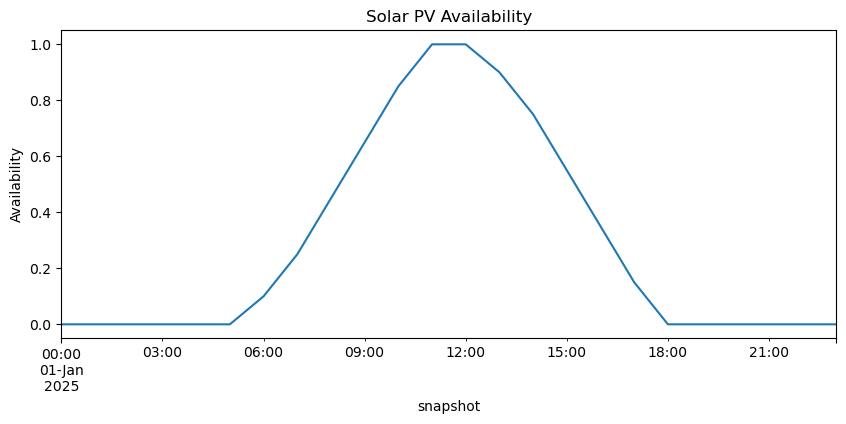

In [167]:
n.generators_t.p_max_pu["solar"].plot(figsize=(10, 4))

plt.ylabel("Availability")
plt.title("Solar PV Availability")
plt.show()

In [168]:
n.add(
    "Generator",
    "gas_1",
    bus="bus_1",
    carrier="gas",
    p_nom=500,
    marginal_cost=50,
)

n.add(
    "Generator",
    "gas_2",
    bus="bus_2",
    carrier="gas",
    p_nom=500,
    marginal_cost=50,
)

n.add(
    "Generator",
    "gas_3",
    bus="bus_3",
    carrier="gas",
    p_nom=500,
    marginal_cost=50,
)

In [169]:
n.add(
    "Line",
    "line_1",
    bus0="bus_1",
    bus1="bus_2",
    x=0.1,
    r=0.01,
    s_nom=200,
    carrier="AC",
)

n.add(
    "Line",
    "line_2",
    bus0="bus_2",
    bus1="bus_3",
    x=0.1,
    r=0.01,
    s_nom=200,
    carrier="AC",
)

n.add(
    "Line",
    "line_3",
    bus0="bus_3",
    bus1="bus_1",
    x=0.1,
    r=0.01,
    s_nom=150,
    carrier="AC",
)

In [170]:
n.optimize()

{'heat_bus'}
{'heat_bus'}
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.02s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 168 primals, 432 duals
Objective: 5.90e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper, Kirchhoff-Voltage-Law were not assigned to the network.


Running HiGHS 1.11.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms
LP   linopy-problem-wyxz9i69 has 432 rows; 168 cols; 648 nonzeros
Coefficient ranges:
  Matrix [1e+00, 1e+04]
  Cost   [5e+01, 5e+01]
  Bound  [0e+00, 0e+00]
  RHS    [3e+01, 5e+02]
Presolving model
96 rows, 156 cols, 300 nonzeros  0s
Dependent equations search running on 96 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
96 rows, 156 cols, 300 nonzeros  0s
Presolve : Reductions: rows 96(-336); columns 156(-12); elements 300(-348)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0    -3.0913380043e-02 Pr: 96(480132) 0s
        112     5.8975000000e+05 Pr: 0(0) 0s
Solving the original LP from the solution after postsolve
Model name          : linopy-problem-wyxz9i69
Model status        : Optimal
Simplex   iterations: 112
Objective value     :  5.

('ok', 'optimal')

In [171]:
n.generators_t.p.head()

Generator,solar,gas_1,gas_2,gas_3
snapshot,,,,
2025-01-01 00:00:00,-0.0,425.0,-0.0,25.0
2025-01-01 01:00:00,-0.0,-0.0,-0.0,425.0
2025-01-01 02:00:00,-0.0,-0.0,410.0,-0.0
2025-01-01 03:00:00,-0.0,-0.0,400.0,-0.0
2025-01-01 04:00:00,-0.0,400.0,-0.0,-0.0


In [172]:
n.lines_t.p0.head()

Line,line_1,line_2,line_3
snapshot,,,
2025-01-01 00:00:00,125.000000,25.000000,-150.000000
2025-01-01 01:00:00,-15.000000,-110.000000,125.000000
2025-01-01 02:00:00,-151.666667,168.333333,-16.666667
2025-01-01 03:00:00,-146.666667,163.333333,-16.666667
2025-01-01 04:00:00,120.000000,30.000000,-150.000000


In [173]:
# n.generators.at["solar", "p_nom"] = 150
n.optimize()

n.generators_t.p.head()


{'heat_bus'}
{'heat_bus'}
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.02s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 168 primals, 432 duals
Objective: 5.90e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper, Kirchhoff-Voltage-Law were not assigned to the network.


Running HiGHS 1.11.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms
LP   linopy-problem-47b2bjl5 has 432 rows; 168 cols; 648 nonzeros
Coefficient ranges:
  Matrix [1e+00, 1e+04]
  Cost   [5e+01, 5e+01]
  Bound  [0e+00, 0e+00]
  RHS    [3e+01, 5e+02]
Presolving model
96 rows, 156 cols, 300 nonzeros  0s
Dependent equations search running on 96 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
96 rows, 156 cols, 300 nonzeros  0s
Presolve : Reductions: rows 96(-336); columns 156(-12); elements 300(-348)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0    -3.0913380043e-02 Pr: 96(480132) 0s
        112     5.8975000000e+05 Pr: 0(0) 0s
Solving the original LP from the solution after postsolve
Model name          : linopy-problem-47b2bjl5
Model status        : Optimal
Simplex   iterations: 112
Objective value     :  5.

Generator,solar,gas_1,gas_2,gas_3
snapshot,,,,
2025-01-01 00:00:00,-0.0,425.0,-0.0,25.0
2025-01-01 01:00:00,-0.0,-0.0,-0.0,425.0
2025-01-01 02:00:00,-0.0,-0.0,410.0,-0.0
2025-01-01 03:00:00,-0.0,-0.0,400.0,-0.0
2025-01-01 04:00:00,-0.0,400.0,-0.0,-0.0


In [174]:
n.add(
    "Load",
    "heat_demand",
    bus="heat_bus"
)

n.loads_t.p_set["heat_demand"] = [
    180, 180, 180, 180, 180, 180,
    170, 160, 150, 140, 130, 120,
    120, 120, 130, 140, 150, 160,
    170, 180, 190, 190, 190, 190
]

In [175]:
n.add(
    "Bus",
    "gas_bus",
    carrier="gas"
)

In [176]:
n.add(
    "Generator",
    "gas_supply",
    bus="gas_bus",
    carrier="gas",
    p_nom=1000,
    marginal_cost=50
)

In [177]:
n.add(
    "Link",
    "CHP",
    bus0="gas_bus",
    bus1="bus_2",
    bus2="heat_bus",
    carrier="CHP",
    p_nom=300,
    efficiency=0.40,
    efficiency2=0.50,
    marginal_cost=0,
)

In [178]:
n.add(
    "Link",
    "boiler",
    bus0="gas_bus",
    bus1="heat_bus",
    carrier="gas boiler",
    p_nom=300,
    efficiency=0.90,
    marginal_cost=5,
)

In [179]:
# n.generators.at["gas_supply", "marginal_cost"] = 20

In [180]:
n.optimize()

Index(['boiler'], dtype='object', name='Link')
Index(['boiler'], dtype='object', name='Link')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.03s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 240 primals, 624 duals
Objective: 8.23e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-fix-p-lower, Link-fix-p-upper, Kirchhoff-Voltage-Law were not assigned to the network.


Running HiGHS 1.11.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms
LP   linopy-problem-mcm4qq6k has 624 rows; 240 cols; 936 nonzeros
Coefficient ranges:
  Matrix [4e-01, 1e+04]
  Cost   [5e+00, 5e+01]
  Bound  [0e+00, 0e+00]
  RHS    [3e+01, 1e+03]
Presolving model
96 rows, 180 cols, 324 nonzeros  0s
Dependent equations search running on 96 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
96 rows, 180 cols, 324 nonzeros  0s
Presolve : Reductions: rows 96(-528); columns 180(-60); elements 324(-612)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     2.3711107924e+05 Pr: 96(480132) 0s
        114     8.2302777778e+05 Pr: 0(0) 0s
Solving the original LP from the solution after postsolve
Model name          : linopy-problem-mcm4qq6k
Model status        : Optimal
Simplex   iterations: 114
Objective value     :  8.

('ok', 'optimal')

In [181]:
n.links_t.p0[["CHP", "boiler"]]

Link,CHP,boiler
snapshot,,
2025-01-01 00:00:00,300.0,33.333333
2025-01-01 01:00:00,300.0,33.333333
2025-01-01 02:00:00,300.0,33.333333
2025-01-01 03:00:00,300.0,33.333333
2025-01-01 04:00:00,300.0,33.333333
2025-01-01 05:00:00,300.0,33.333333
2025-01-01 06:00:00,300.0,22.222222
2025-01-01 07:00:00,300.0,11.111111
2025-01-01 08:00:00,300.0,-0.000000


In [182]:
n.links.at["CHP", "p_nom"] = 0
n.optimize()

obj_no_chp = n.objective

Index(['boiler'], dtype='object', name='Link')
Index(['boiler'], dtype='object', name='Link')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.03s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 240 primals, 624 duals
Objective: 8.27e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-fix-p-lower, Link-fix-p-upper, Kirchhoff-Voltage-Law were not assigned to the network.


Running HiGHS 1.11.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms
LP   linopy-problem-yvrce09l has 624 rows; 240 cols; 936 nonzeros
Coefficient ranges:
  Matrix [4e-01, 1e+04]
  Cost   [5e+00, 5e+01]
  Bound  [0e+00, 0e+00]
  RHS    [3e+01, 1e+03]
Presolving model
96 rows, 156 cols, 300 nonzeros  0s
Dependent equations search running on 96 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
96 rows, 156 cols, 300 nonzeros  0s
Presolve : Reductions: rows 96(-528); columns 156(-84); elements 300(-636)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     2.3711108020e+05 Pr: 96(480132) 0s
        112     8.2686111111e+05 Pr: 0(0) 0s
Solving the original LP from the solution after postsolve
Model name          : linopy-problem-yvrce09l
Model status        : Optimal
Simplex   iterations: 112
Objective value     :  8.

In [183]:
n.links.at["CHP", "p_nom"] = 300
n.optimize()

obj_chp = n.objective

Index(['boiler'], dtype='object', name='Link')
Index(['boiler'], dtype='object', name='Link')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.03s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 240 primals, 624 duals
Objective: 8.23e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-fix-p-lower, Link-fix-p-upper, Kirchhoff-Voltage-Law were not assigned to the network.


Running HiGHS 1.11.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms
LP   linopy-problem-tzlue3cy has 624 rows; 240 cols; 936 nonzeros
Coefficient ranges:
  Matrix [4e-01, 1e+04]
  Cost   [5e+00, 5e+01]
  Bound  [0e+00, 0e+00]
  RHS    [3e+01, 1e+03]
Presolving model
96 rows, 180 cols, 324 nonzeros  0s
Dependent equations search running on 96 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
96 rows, 180 cols, 324 nonzeros  0s
Presolve : Reductions: rows 96(-528); columns 180(-60); elements 324(-612)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     2.3711107924e+05 Pr: 96(480132) 0s
        114     8.2302777778e+05 Pr: 0(0) 0s
Solving the original LP from the solution after postsolve
Model name          : linopy-problem-tzlue3cy
Model status        : Optimal
Simplex   iterations: 114
Objective value     :  8.

In [184]:
n.loads_t.p_set["heat_demand"].head(10)

snapshot
2025-01-01 00:00:00    180
2025-01-01 01:00:00    180
2025-01-01 02:00:00    180
2025-01-01 03:00:00    180
2025-01-01 04:00:00    180
2025-01-01 05:00:00    180
2025-01-01 06:00:00    170
2025-01-01 07:00:00    160
2025-01-01 08:00:00    150
2025-01-01 09:00:00    140
Freq: h, Name: heat_demand, dtype: int64

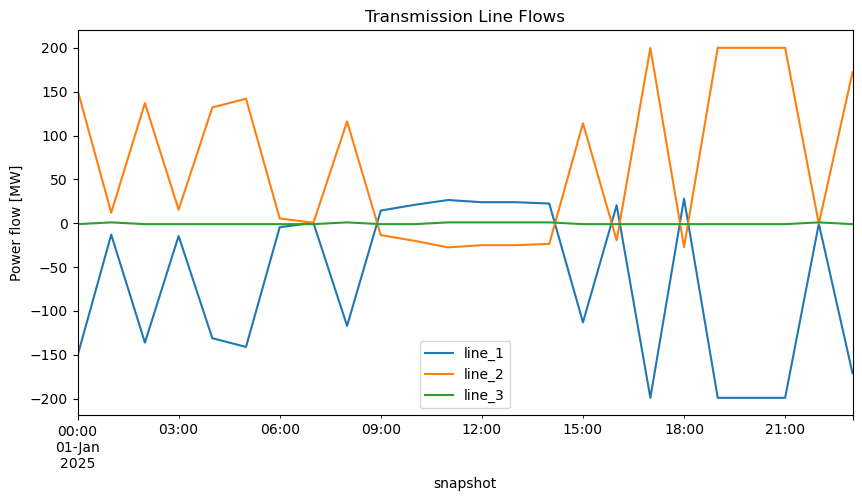

In [158]:
n.lines_t.p0.plot(figsize=(10, 5))

plt.ylabel("Power flow [MW]")
plt.title("Transmission Line Flows")
plt.legend()
plt.show()

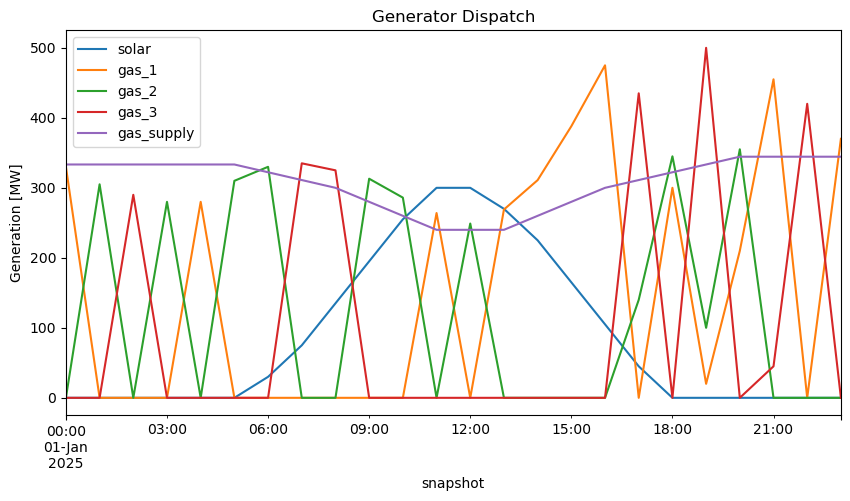

In [187]:
n.generators_t.p.plot(figsize=(10, 5))

plt.ylabel("Generation [MW]")
plt.title("Generator Dispatch")
plt.legend()
plt.show()

In [188]:
m = n.model
m.variables
m.constraints

linopy.model.Constraints
------------------------
 * Generator-fix-p-lower (snapshot, Generator-fix)
 * Generator-fix-p-upper (snapshot, Generator-fix)
 * Line-fix-s-lower (snapshot, Line-fix)
 * Line-fix-s-upper (snapshot, Line-fix)
 * Link-fix-p-lower (snapshot, Link-fix)
 * Link-fix-p-upper (snapshot, Link-fix)
 * Bus-nodal_balance (Bus, snapshot)
 * Kirchhoff-Voltage-Law (snapshot, cycles)

In [189]:
m.to_file("Assignment_week2.lp")

INFO:linopy.io: Writing time: 0.08s


PosixPath('Assignment_week2.lp')

In [190]:
m.solve(solver_name="highs", output_flag=False)

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - output_flag: False
INFO:linopy.io: Writing time: 0.03s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 240 primals, 624 duals
Objective: 8.23e+05
Solver model: available
Solver message: Optimal



Running HiGHS 1.11.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms


('ok', 'optimal')